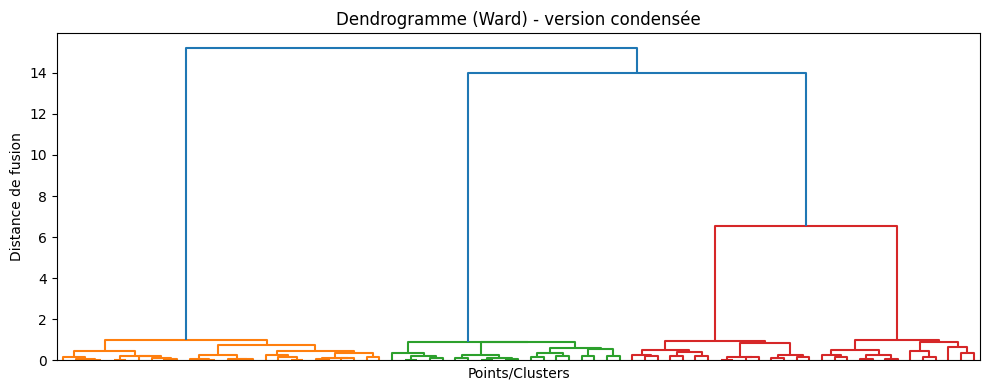

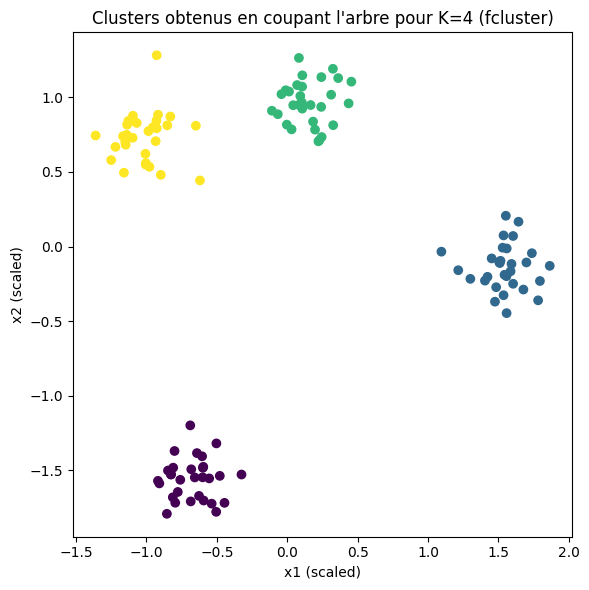

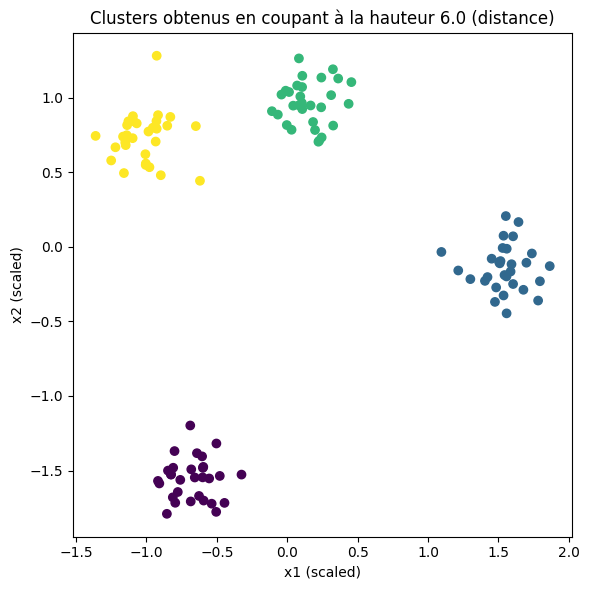

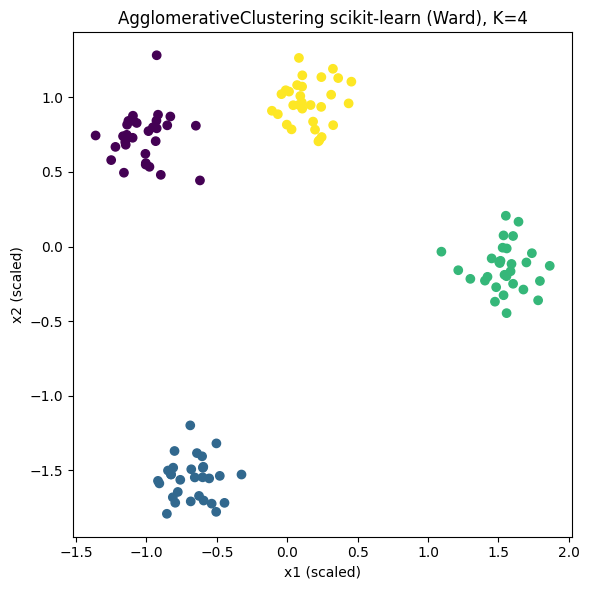

In [ ]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# ----------------------------
# 1) Jeu de données (exemple simple)
# ----------------------------
X, _ = make_blobs(n_samples=120, centers=4, cluster_std=0.9, random_state=42)

# Scaling (souvent indispensable avec des distances)
X = StandardScaler().fit_transform(X)

# ----------------------------
# 2) Construire la hiérarchie (pour dendrogramme)
# ----------------------------
# linkage construit l'arbre de fusions.
# method='ward' = Ward linkage (très courant), metric='euclidean' requis pour ward.
Z = linkage(X, method="ward", metric="euclidean")

plt.figure(figsize=(10, 4))
dendrogram(
    Z,
    truncate_mode="level",  # affiche une version condensée (plus lisible)
    p=6,  # nb de niveaux affichés
    no_labels=True,
)
plt.title("Dendrogramme (Ward) - version condensée")
plt.xlabel("Points/Clusters")
plt.ylabel("Distance de fusion")
plt.tight_layout()
plt.show()

# ----------------------------
# 3) Obtenir des clusters en "coupant" le dendrogramme
# ----------------------------

# Option A — Couper pour avoir exactement K clusters
K = 4
labels_from_cut = fcluster(Z, t=K, criterion="maxclust")  # labels: 1..K

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels_from_cut)
plt.title(f"Clusters obtenus en coupant l'arbre pour K={K} (fcluster)")
plt.xlabel("x1 (scaled)")
plt.ylabel("x2 (scaled)")
plt.tight_layout()
plt.show()

# Option B — Couper à une HAUTEUR (distance) donnée
# Exemple : si tu vois une grosse marche dans le dendrogramme vers ~6,
# tu peux couper à une hauteur juste en dessous.
cut_height = 6.0
labels_from_height = fcluster(Z, t=cut_height, criterion="distance")

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels_from_height)
plt.title(f"Clusters obtenus en coupant à la hauteur {cut_height} (distance)")
plt.xlabel("x1 (scaled)")
plt.ylabel("x2 (scaled)")
plt.tight_layout()
plt.show()

# ----------------------------
# 4) Variante scikit-learn : obtenir directement K clusters (sans dendrogramme)
# ----------------------------
model = AgglomerativeClustering(n_clusters=K, linkage="ward")
labels_sklearn = model.fit_predict(X)  # labels: 0..K-1

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels_sklearn)
plt.title(f"AgglomerativeClustering scikit-learn (Ward), K={K}")
plt.xlabel("x1 (scaled)")
plt.ylabel("x2 (scaled)")
plt.tight_layout()
plt.show()
